In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import h5py
import importlib
from importlib.util import find_spec
from IPython.display import display

# Support opening notebooks from the root of the repository
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if not (ROOT / "src" / "observations.py").is_file():
    raise RuntimeError("Open the this notebook from the repo root or notebooks folder.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.observations import load_spectrum
import src.instrument as instrument
import src.snr_sweep as sweep
import src.build_cos_features as cos
from src import cos_overlay
from src import cos_oracle

In [2]:
spectrum = load_spectrum(ROOT / "data" / "raw" / "observations" / "pg1048_all.dat")

forest = (spectrum.wavelength >= 1220.0) & (spectrum.wavelength <= 1380.0)

wavelength = spectrum.wavelength[forest]
valid = spectrum.valid[forest]

# NaNs break the plotly line plot, so we need to filter them out
# original spectrum is preserved in the `spectrum` variable

flux_plot = np.where(valid, spectrum.flux[forest], np.nan)
error_plot = np.where(valid, spectrum.error[forest], np.nan)

In [3]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=wavelength,
        y=flux_plot,
        customdata=error_plot,
        mode="lines",
        name="Normalized Flux",
        line=dict(color='#24476B', width=1),
        connectgaps=False,
        hovertemplate=(
            "Wavelength: %{x:.3f} Å"
            "<br>Normalized Flux: %{y:.3f}"
            "<br>Flux Error: %{customdata:.3f}"
            "<extra></extra>"
        ),
    )
)

fig.add_hline(y=1.0, line_dash="dash", line_color="gray")

fig.update_layout(
    title="COS Spectrum of PG1048 - candidate Lyman-alpha Forest Region",
    xaxis_title="Wavelength (Å)",
    yaxis_title="Normalized Flux",
    template="plotly_white",
    height=500,
    xaxis=dict(
        range=[1220, 1380],
        rangeslider=dict(visible=True, thickness=0.12)
    ),
)

fig.show(config={"scrollZoom": True})

In [4]:
overview = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3],
    vertical_spacing=0.08,
)

# Reuse the flux trace from the first figure.
overview.add_trace(fig.data[0], row=1, col=1)

overview.add_trace(
    go.Scatter(
        x=wavelength,
        y=error_plot,
        mode="lines",
        name="Reported uncertainty",
        line=dict(color="#B45309", width=1),
        connectgaps=False,
        hovertemplate=(
            "Wavelength: %{x:.3f} Å"
            "<br>Reported error: %{y:.4f}"
            "<extra></extra>"
        ),
    ),
    row=2,
    col=1,
)

overview.add_hline(
    y=1.0, line_dash="dash", line_color="gray", row=1, col=1
)

overview.update_yaxes(title_text="Normalized flux", row=1, col=1)
overview.update_yaxes(
    title_text="Reported 1σ error",
    rangemode="tozero",
    row=2,
    col=1,
)
overview.update_xaxes(
    title_text="Observed wavelength [Å]", row=2, col=1
)
overview.update_xaxes(range=[1220.0, 1380.0])

overview.update_layout(
    title="pg1048_all.dat — spectrum and uncertainty",
    template="plotly_white",
    height=650,
    showlegend=False,
)

overview.show(config={"scrollZoom": True})

median_error = np.nanmedian(error_plot)
print(f"Median normalized uncertainty: {median_error:.4f}")
print(f"Approximate continuum S/N: {1.0 / median_error:.1f} per pixel")

Median normalized uncertainty: 0.0700
Approximate continuum S/N: 14.3 per pixel


In [5]:
C_KMS = 299792.458
LOS_LENGTH_KMS = 2500.0

usable_indices = np.flatnonzero(forest & spectrum.valid)

if usable_indices.size < 2:
    raise ValueError("Not enough usable pixels in the selected range.")

typical_spacing = np.median(
    np.diff(spectrum.wavelength[forest])
)

# Split at excluded rows or unusually large wavelength jumps.
breaks = (
    (np.diff(usable_indices) > 1)
    | (
        np.diff(spectrum.wavelength[usable_indices])
        > 3.0 * typical_spacing
    )
)

split_positions = np.flatnonzero(breaks) + 1
segments = np.split(usable_indices, split_positions)

rows = []

for number, indices in enumerate(segments, start=1):
    wave = spectrum.wavelength[indices]

    # Use pixel-center endpoints for a conservative coverage estimate.
    span_kms = C_KMS * np.log(wave[-1] / wave[0])
    full_los = int(np.floor(span_kms / LOS_LENGTH_KMS))

    rows.append({
        "segment": number,
        "start_A": wave[0],
        "end_A": wave[-1],
        "pixels": len(wave),
        "span_kms": span_kms,
        "full_LOS": full_los,
    })

coverage = pd.DataFrame(rows)

display(
    coverage.round({
        "start_A": 2,
        "end_A": 2,
        "span_kms": 1,
    })
)

print(f"Total full simulation-length chunks: {coverage['full_LOS'].sum()}")

,segment,start_A,end_A,pixels,span_kms,full_LOS
0,1,1220.02,1300.99,2711,19264.5,7
1,2,1306.91,1379.99,2447,16312.7,6


Total full simulation-length chunks: 13


In [6]:
lsf_path = (
    ROOT / "data" / "reference" / "cos_lsf"
    / "aa_LSFTable_G130M_1291_LP1_cn.dat"
)

lsf_wavelengths, lsf_kernels = instrument.load_cos_lsf(lsf_path)

print(f"Wavelength range: {lsf_wavelengths[0]:.0f}–{lsf_wavelengths[-1]:.0f} Å")
print(f"Kernel array shape: {lsf_kernels.shape}")

np.testing.assert_allclose(
    lsf_kernels.sum(axis=0),
    1.0,
    rtol=0.0,
    atol=1e-12,
)

Wavelength range: 1134–1430 Å
Kernel array shape: (321, 57)


In [7]:
TARGET_WAVELENGTH_A = 1300.0
DISPERSION_A_PER_PIXEL = 0.00997  # Nominal G130M dispersion
GAUSSIAN_SIGMA_KMS = 7.96
C_KMS = 299792.458

# Select the closest tabulated wavelength.
index = int(np.argmin(np.abs(lsf_wavelengths - TARGET_WAVELENGTH_A)))
lsf_wave = float(lsf_wavelengths[index])
lsf_kernel = lsf_kernels[:, index]

# Convert native LSF pixel offsets to approximate velocity offsets.
pixel_offsets = np.arange(lsf_kernel.size) - lsf_kernel.size // 2
dv_lsf = C_KMS * DISPERSION_A_PER_PIXEL / lsf_wave
lsf_velocity = pixel_offsets * dv_lsf

# Evaluate the previous Gaussian approximation on the same grid.
gaussian_kernel = np.exp(
    -0.5 * (lsf_velocity / GAUSSIAN_SIGMA_KMS) ** 2
)
gaussian_kernel /= gaussian_kernel.sum()

lsf_fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Line core", "Wings — logarithmic scale"],
)

profiles = [
    ("COS LP1", lsf_kernel, "#24476B"),
    ("Gaussian σ = 7.96 km/s", gaussian_kernel, "#B45309"),
]

for label, kernel, color in profiles:
    density = kernel / dv_lsf

    for column in (1, 2):
        # Zero values cannot be displayed on a logarithmic axis.
        plotted = density if column == 1 else np.where(
            density > 0.0, density, np.nan
        )

        lsf_fig.add_trace(
            go.Scatter(
                x=lsf_velocity,
                y=plotted,
                mode="lines",
                name=label,
                legendgroup=label,
                showlegend=(column == 1),
                line=dict(color=color, width=2),
                connectgaps=False,
            ),
            row=1,
            col=column,
        )

lsf_fig.update_xaxes(title_text="Velocity offset [km/s]")
lsf_fig.update_xaxes(range=[-60, 60], row=1, col=1)
lsf_fig.update_xaxes(
    range=[lsf_velocity[0], lsf_velocity[-1]], row=1, col=2
)
lsf_fig.update_yaxes(title_text="LSF density [(km/s)⁻¹]")
lsf_fig.update_yaxes(type="log", range=[-7, -1], row=1, col=2)

lsf_fig.update_layout(
    title=f"LP1 / assumed G130M 1291 — LSF at {lsf_wave:.0f} Å",
    template="plotly_white",
    height=450,
    legend=dict(orientation="h", y=-0.25),
)
lsf_fig.show(config={"scrollZoom": True})

print(f"Native LSF sampling: {dv_lsf:.3f} km/s per pixel")

Native LSF sampling: 2.299 km/s per pixel


In [8]:
importlib.reload(instrument)

dv_sim = 2500.0 / 2499
kernel_sim = instrument.resample_lsf(
    lsf_kernel,
    dv_in=dv_lsf,
    dv_out=dv_sim,
)

print(f"Simulation sampling: {dv_sim:.6f} km/s per pixel")
print(f"Kernel length: {kernel_sim.size}")
print(f"Kernel sum: {kernel_sim.sum():.12f}")

np.testing.assert_allclose(
    kernel_sim.sum(), 1.0, rtol=0.0, atol=1e-12
)
assert np.all(kernel_sim >= 0.0)
assert kernel_sim.size % 2 == 1

Simulation sampling: 1.000400 km/s per pixel
Kernel length: 739
Kernel sum: 1.000000000000


In [9]:
importlib.reload(instrument)

# Two diagnostic inputs: a flat continuum and a varying spectrum.
probe = np.vstack([
    np.ones(2499),
    np.linspace(0.0, 1.0, 2499),
])

smoothed, dv_out = instrument.apply_cos_lsf(
    probe,
    dv_sim=dv_sim,
    kernel=kernel_sim,
)

assert smoothed.shape == probe.shape
assert dv_out == dv_sim

# A flat continuum should remain flat.
np.testing.assert_allclose(
    smoothed[0], probe[0], rtol=0.0, atol=1e-12
)

# Each sightline should retain its own mean flux.
np.testing.assert_allclose(
    smoothed.mean(axis=-1),
    probe.mean(axis=-1),
    rtol=0.0,
    atol=1e-12,
)

print("Convolution checks passed.")

Convolution checks passed.


In [10]:
MOCK_MODEL = "EX3"
MOCK_LOS = 9000

calibration_path = (
    ROOT / "outputs" / "uvb_mean_flux" / "calibration"
    / "z0_b15_seed42.json"
)

with calibration_path.open() as handle:
    calibration = json.load(handle)

if calibration["redshift"] != 0.0:
    raise ValueError("This example assumes z = 0")

tau_scale = float(calibration["results"][MOCK_MODEL]["tau_scale"])

if not np.isfinite(tau_scale) or tau_scale <= 0.0:
    raise ValueError("Expected a positive, finite optical-depth scale")

mock_path = ROOT / "data" / "raw" / f"{MOCK_MODEL}_spectra.hdf5"

# Read only the selected sightline.
with h5py.File(mock_path, "r") as handle:
    tau_mock = np.asarray(
        handle[calibration["tau_key"]][MOCK_LOS, :],
        dtype=np.float64,
    )

if tau_mock.ndim != 1 or tau_mock.size < 2:
    raise ValueError("Expected one sightline with at least two pixels")

if not np.all(np.isfinite(tau_mock)) or np.any(tau_mock < 0.0):
    raise ValueError("Optical depth must be finite and nonnegative")

flux_native = np.exp(-tau_scale * tau_mock)
dv_mock = 2500.0 / flux_native.size
velocity_mock = np.arange(flux_native.size) * dv_mock

# Prepare the LSF using this sightline's actual pixel spacing.
kernel_mock = instrument.resample_lsf(
    lsf_kernel,
    dv_in=dv_lsf,
    dv_out=dv_mock,
)

flux_cos, _ = instrument.apply_cos_lsf(
    flux_native,
    dv_sim=dv_mock,
    kernel=kernel_mock,
)

flux_gaussian, _ = instrument.apply_cos_gaussian(
    flux_native,
    dv_sim=dv_mock,
    sigma_kms=7.96,
    truncate=8.0,
)

np.testing.assert_allclose(
    [flux_cos.mean(), flux_gaussian.mean()],
    flux_native.mean(),
    rtol=0.0,
    atol=1e-12,
)

mock_fig = go.Figure()

for label, values, color, dash in [
    ("Native mock", flux_native, "#808080", "dot"),
    ("Gaussian σ = 7.96 km/s", flux_gaussian, "#B45309", "dash"),
    ("COS LP1", flux_cos, "#24476B", "solid"),
]:
    mock_fig.add_trace(
        go.Scatter(
            x=velocity_mock,
            y=values,
            mode="lines",
            name=label,
            line=dict(color=color, dash=dash, width=1.5),
            hovertemplate=(
                "Velocity: %{x:.1f} km/s"
                "<br>Flux: %{y:.4f}"
                "<extra>%{fullData.name}</extra>"
            ),
        )
    )

mock_fig.update_layout(
    title=(
        f"{MOCK_MODEL}, sightline {MOCK_LOS} — mean-flux matched"
        f"<br><sup>LP1; assumed G130M/1291; "
        f"single LSF profile at {lsf_wave:.0f} Å</sup>"
    ),
    xaxis_title="Velocity along the simulated sightline [km/s]",
    yaxis_title="Normalized flux",
    template="plotly_white",
    height=500,
    hovermode="x unified",
    legend=dict(orientation="h", y=1.01),
    xaxis=dict(rangeslider=dict(visible=True, thickness=0.1)),
)

mock_fig.show(config={"scrollZoom": True})
print(f"Mean-flux checks passed. Native mean: {flux_native.mean():.6f}")

Mean-flux checks passed. Native mean: 0.901039


In [11]:
NOISE_SEED = 42

# Estimate the sampling of the spectrum using the adjacent valid pixels.
obs_wave = spectrum.wavelength
usable = forest & spectrum.valid
adjacent = usable[1:] & usable[:-1]
adjacent &= np.diff(obs_wave) < 3.0 * typical_spacing # = np.median(np.diff(spectrum.wavelength[forest]))

observed_dv = C_KMS * np.log(obs_wave[1:][adjacent] / obs_wave[:-1][adjacent])
dv_target = float(np.median(observed_dv))
sigma_pilot = float(np.median(spectrum.error[usable]))

# Preserve the full simulation length of 2500 km/s when choosing the output size. This is a convenient choice for later analysis, but it is not strictly necessary.
length_kms = flux_cos.size * dv_mock
n_pilot = int(np.rint(length_kms / dv_target))

flux_pilot_clean, dv_pilot = instrument.resample_flux(flux_cos, dv_in=dv_mock, n_pixels_out=n_pilot)

# Coordinates at the center of each resampled bin.
velocity_pilot = (np.arange(n_pilot) + 0.5) * dv_pilot

np.testing.assert_allclose(flux_pilot_clean.mean(), flux_cos.mean(), rtol=0.0, atol=1e-12)

# Add Gaussian noise to the flux after convolution and resampling. The noise is independent of the flux value, which is a reasonable approximation for the COS data.
rng = np.random.default_rng(NOISE_SEED)
flux_pilot_noisy = flux_pilot_clean + rng.normal(loc=0.0, scale=sigma_pilot, size=flux_pilot_clean.shape)

noise_fig = go.Figure()

noise_fig.add_trace(
    go.Scatter(
        x=velocity_pilot,
        y=flux_pilot_noisy,
        mode="lines+markers",
        name="Mock spectrum with noise",
        marker=dict(color="#24476B", size=4),
        error_y=dict(
            type="constant",
            value=sigma_pilot,
            color="#9CA3AF",
            thickness=0.6,
            width=0,
        ),
    )
)

noise_fig.add_trace(
    go.Scatter(
        x=velocity_pilot,
        y=flux_pilot_clean,
        mode="lines",
        name="COS-convolved, resampled, noise-free",
        line=dict(color="#B45309", width=2),
    )
)

noise_fig.update_layout(
    title=(
        f"{MOCK_MODEL}, sightline {MOCK_LOS} — noise test"
        f"<br><sup>LP1; assumed G130M/1291 at {lsf_wave:.0f} Å; σ = {sigma_pilot:.4f}</sup>"
        f"continuum S/N ≈ {1.0 / sigma_pilot:.1f} per pixel</sup>"
    ),
    xaxis_title="Velocity along the simulated sightline [km/s]",
    yaxis_title="Normalized flux",
    template="plotly_white",
    height=500,
    hovermode="x unified",
    legend=dict(orientation="h", y=1.02),
    xaxis=dict(rangeslider=dict(visible=True, thickness=0.1)),
)

noise_fig.show(config={"scrollZoom": True})

print(f"Pixels: {flux_cos.size} → {n_pilot} (resampled)")
print(f"Output pixel spacing: {dv_pilot:.6f} km/s")
print(f"Noise level: {sigma_pilot:.4f}")
print(f"Continuum S/N: {1.0 / sigma_pilot:.2f} per pixel (approximate)")

Pixels: 2499 → 362 (resampled)
Output pixel spacing: 6.906077 km/s
Noise level: 0.0700
Continuum S/N: 14.29 per pixel (approximate)


In [12]:
lp1_summary_path = ROOT / (
    "outputs/cos_lsf_snr/summary/"
    "z0_b15_s42_four_class_lp1_obs.json"
)
with lp1_summary_path.open() as handle:
    lp1_summary = json.load(handle)

lp1_stages = ("lp1_obs_clean", "lp1_obs_noisy")
lp1_labels = ["LP1: no added noise", "LP1: S/N ≈ 14.3/pixel"]

lp1_accuracy = 100 * np.array([
    lp1_summary["accuracy"][stage]["accuracy"] for stage in lp1_stages
])
lp1_low = 100 * np.array([
    lp1_summary["accuracy"][stage]["ci_low"] for stage in lp1_stages
])
lp1_high = 100 * np.array([
    lp1_summary["accuracy"][stage]["ci_high"] for stage in lp1_stages
])
lp1_change = lp1_summary["changes"]["lp1_obs_noisy - lp1_obs_clean"]

fig_lp1_accuracy = go.Figure(go.Scatter(
    x=lp1_accuracy,
    y=lp1_labels,
    mode="markers+text",
    text=[f"{value:.2f}%" for value in lp1_accuracy],
    textposition="top center",
    marker=dict(size=13, color=["#0072B2", "#D55E00"]),
    error_x=dict(
        type="data",
        symmetric=False,
        array=lp1_high - lp1_accuracy,
        arrayminus=lp1_accuracy - lp1_low,
        color="#444444",
        thickness=2,
        width=7,
    ),
    customdata=np.column_stack([lp1_low, lp1_high]),
    hovertemplate=(
        "%{y}<br>Accuracy: %{x:.2f}%"
        "<br>95% CI: [%{customdata[0]:.2f}, %{customdata[1]:.2f}]%"
        "<extra></extra>"
    ),
))

fig_lp1_accuracy.add_vline(
    x=25,
    line_dash="dash",
    line_color="gray",
    annotation_text="Chance: 25%",
    annotation_position="top right",
)
fig_lp1_accuracy.update_layout(
    title=dict(text=(
        "LP1 mock pilot: four-class classification"
        "<br><sup>15 sightlines per bundle · "
        "95% paired-bundle bootstrap intervals</sup>"
    )),
    template="plotly_white",
    height=440,
    margin=dict(l=190, r=40, t=90, b=120),
    showlegend=False,
    xaxis=dict(title="Held-out accuracy (%)", range=[0, 100]),
    yaxis=dict(
        categoryorder="array",
        categoryarray=lp1_labels,
        autorange="reversed",
    ),
)
fig_lp1_accuracy.add_annotation(
    x=0,
    y=-0.30,
    xref="paper",
    yref="paper",
    xanchor="left",
    yanchor="top",
    showarrow=False,
    align="left",
    text=(
        f"Noisy − clean: <b>{lp1_change['difference_pp']:+.2f} pp</b>"
        f" (95% CI [{lp1_change['ci_low_pp']:+.2f}, "
        f"{lp1_change['ci_high_pp']:+.2f}] pp)<br>"
        "Provisional G130M/1291 at 1300 Å; Gaussian noise σ = 0.07."
    ),
)
fig_lp1_accuracy.show()

In [13]:
lp1_runs_root = ROOT / "outputs/cos_lsf_snr/runs"
lp1_run_suffix = "z0_b15_s42/matched/EX0_EX1_EX2_EX3"

fig_lp1_cm = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("No added noise", "S/N ≈ 14.3/pixel"),
    horizontal_spacing=0.16,
)

for column, stage in enumerate(lp1_stages, start=1):
    metrics_path = (
        lp1_runs_root / stage / lp1_run_suffix / "metrics.json"
    )
    with metrics_path.open() as handle:
        metrics = json.load(handle)

    labels = metrics["models"]
    counts = np.asarray(metrics["confusion_matrix"], dtype=int)
    row_totals = counts.sum(axis=1, keepdims=True)

    if np.any(row_totals == 0):
        raise ValueError(f"{stage}: a true class has no test examples")

    percentages = 100.0 * counts / row_totals

    fig_lp1_cm.add_trace(
        go.Heatmap(
            z=percentages,
            x=labels,
            y=labels,
            coloraxis="coloraxis",
            customdata=counts,
            texttemplate="%{z:.1f}%",
            hovertemplate=(
                "True model: %{y}<br>"
                "Predicted model: %{x}<br>"
                "Count: %{customdata}<br>"
                "Within true class: %{z:.1f}%"
                "<extra></extra>"
            ),
        ),
        row=1,
        col=column,
    )
    fig_lp1_cm.update_xaxes(
        title_text="Predicted model",
        row=1,
        col=column,
    )
    fig_lp1_cm.update_yaxes(
        title_text="True model",
        autorange="reversed",
        row=1,
        col=column,
    )

    print(f"\n{stage} — label order: {labels}")
    print(counts)

fig_lp1_cm.update_layout(
    title="LP1 pilot: confusion matrices",
    template="plotly_white",
    height=470,
    margin=dict(l=70, r=100, t=90, b=70),
    coloraxis=dict(
        colorscale="Blues",
        cmin=0,
        cmax=100,
        colorbar=dict(title="Within true<br>class (%)"),
    ),
)
fig_lp1_cm.show()


lp1_obs_clean — label order: ['EX0', 'EX1', 'EX2', 'EX3']
[[33 42 30 29]
 [24 70 16 24]
 [23 17 76 18]
 [14 13  9 98]]

lp1_obs_noisy — label order: ['EX0', 'EX1', 'EX2', 'EX3']
[[42 37 32 23]
 [28 31 42 33]
 [32 27 57 18]
 [24 30 22 58]]


In [14]:
STRONG_FLUX_MAX = 0.85
HALF_WINDOW_KMS = 250.0
MAX_CANDIDATES = 8
C_KMS = 299792.458

obs_wave = spectrum.wavelength
obs_flux = spectrum.flux
obs_error = spectrum.error

obs_forest = (obs_wave >= 1220.0) & (obs_wave <= 1380.0)
obs_usable = obs_forest & spectrum.valid
obs_forest_wave = obs_wave[obs_forest]
obs_spacing = np.median(np.diff(obs_forest_wave))

candidate_pool = np.flatnonzero(
    obs_usable & (obs_flux < STRONG_FLUX_MAX)
)
candidate_pool = candidate_pool[
    np.argsort(obs_flux[candidate_pool], kind="stable")
]

strong_centers = []

for index in candidate_pool:
    # Consider the deepest pixels first; keep separate windows.
    overlaps = any(
        abs(C_KMS * np.log(obs_wave[index] / obs_wave[other]))
        < 2 * HALF_WINDOW_KMS
        for other in strong_centers
    )
    if overlaps:
        continue

    left, right = obs_wave[index] * np.exp(
        np.array([-HALF_WINDOW_KMS, HALF_WINDOW_KMS]) / C_KMS
    )

    if left < obs_forest_wave[0] or right > obs_forest_wave[-1]:
        continue

    window = (obs_wave >= left) & (obs_wave <= right)

    if window.sum() < 3 or not np.all(obs_usable[window]):
        continue

    if np.any(np.diff(obs_wave[window]) > 3 * obs_spacing):
        continue

    strong_centers.append(int(index))

    if len(strong_centers) == MAX_CANDIDATES:
        break

if not strong_centers:
    raise ValueError("No strong-trough windows have complete valid coverage")

strong_candidate_table = pd.DataFrame({
    "center_A": obs_wave[strong_centers],
    "flux_at_center": obs_flux[strong_centers],
    "error_at_center": obs_error[strong_centers],
})

strong_candidate_table

,center_A,flux_at_center,error_at_center
0,1222.6501,0.0020,0.0111
1,1334.4863,0.0030,0.0181
2,1260.3870,0.0134,0.0132
3,1287.7261,0.0622,0.0402
4,1344.4957,0.2692,0.0482
5,1253.6045,0.3281,0.0352
6,1285.3358,0.3842,0.0621
7,1258.1760,0.3931,0.0365


In [15]:
fig_strong = go.Figure()
window_titles = []
y_low, y_high = 0.0, 1.0

for number, index in enumerate(strong_centers):
    center = obs_wave[index]
    velocity = C_KMS * np.log(obs_wave / center)
    window = np.abs(velocity) <= HALF_WINDOW_KMS

    window_flux = obs_flux[window]
    window_error = obs_error[window]

    y_low = min(y_low, float(np.min(window_flux - window_error)))
    y_high = max(y_high, float(np.max(window_flux + window_error)))

    window_titles.append(
        f"Strong-trough inspection: {center:.4f} Å"
        "<br><sup>Center = selected flux minimum; line identification pending</sup>"
    )

    fig_strong.add_trace(go.Scatter(
        x=velocity[window],
        y=window_flux,
        mode="lines+markers",
        line=dict(color="#0072B2", width=1.5),
        marker=dict(size=3),
        error_y=dict(
            type="data",
            array=window_error,
            visible=True,
            color="#999999",
            thickness=0.7,
            width=0,
        ),
        customdata=np.column_stack([
            obs_wave[window],
            window_error,
        ]),
        hovertemplate=(
            "λ: %{customdata[0]:.4f} Å<br>"
            "Velocity: %{x:.1f} km/s<br>"
            "Flux: %{y:.3f}<br>"
            "Reported error: %{customdata[1]:.3f}"
            "<extra></extra>"
        ),
        connectgaps=False,
        visible=(number == 0),
    ))

padding = 0.05 * (y_high - y_low)
shared_y_range = [y_low - padding, y_high + padding]
velocity_range = [-HALF_WINDOW_KMS, HALF_WINDOW_KMS]

buttons = []
for number, index in enumerate(strong_centers):
    visibility = [False] * len(strong_centers)
    visibility[number] = True

    buttons.append(dict(
        label=f"{number + 1}: {obs_wave[index]:.4f} Å",
        method="update",
        args=[
            {"visible": visibility},
            {
                "title.text": window_titles[number],
                "xaxis.range": velocity_range,
                "yaxis.range": shared_y_range,
            },
        ],
    ))

fig_strong.add_hline(y=1.0, line_color="gray", line_width=1)
fig_strong.add_hline(
    y=STRONG_FLUX_MAX,
    line_dash="dot",
    line_color="gray",
    annotation_text=f"F = {STRONG_FLUX_MAX:.2f}",
    annotation_position="bottom right",
)
fig_strong.add_vline(
    x=0,
    line_dash="dot",
    line_color="gray",
    opacity=0.5,
)

fig_strong.update_layout(
    title=dict(text=window_titles[0], x=0.02, y=0.95),
    template="plotly_white",
    height=500,
    margin=dict(l=70, r=40, t=125, b=65),
    showlegend=False,
    xaxis=dict(
        title="Velocity relative to selected center (km/s)",
        range=velocity_range,
    ),
    yaxis=dict(title="Normalized flux", range=shared_y_range),
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0,
        y=1.15,
        xanchor="left",
        yanchor="top",
    )],
)
fig_strong.show()

## Preliminary classification of pg1048 using 13-LOS bundles

**Question:** Which of EX0–EX3 receives the highest classifier score for
the observed spectrum?

Each input combines 13 spectral chunks of 2500 km/s each, giving a total
velocity path of 32,500 km/s.

### Observed chunk selection

Select complete, non-overlapping chunks within 1220–1380 Å. Start at the
first valid wavelength of each continuous segment. Exclude invalid pixels
and the known gap near 1300 Å.

Selection uses wavelength coverage and valid reported errors. ISM, metal,
and intrinsic absorption masks remain pending.

### Planned comparison

Train one four-class XGBoost classifier using the existing noisy LP1 mock
features, regrouped into 13-LOS bundles while preserving the original
training/test separation. Resample each observed chunk to the same
362-pixel velocity grid and apply the same feature extraction.

The output is an exploratory classifier preference. Interpretation depends
on the provisional instrument/noise assumptions, continuum normalization,
line contamination, and the use of z = 0 simulations.

In [16]:
BUNDLE_SIZE = 13
CHUNK_PIXELS = 362
CHUNK_DV = LOS_LENGTH_KMS / CHUNK_PIXELS

chunk_rows = []

for segment_id, indices in enumerate(segments, start=1):
    segment_wave = spectrum.wavelength[indices]
    span = C_KMS * np.log(segment_wave[-1] / segment_wave[0])
    n_chunks = int(np.floor(span / LOS_LENGTH_KMS))

    for j in range(n_chunks):
        # Fixed velocity intervals, anchored at this segment's start.
        left, right = segment_wave[0] * np.exp(
            np.array([j, j + 1]) * LOS_LENGTH_KMS / C_KMS
        )

        selected = indices[
            (segment_wave >= left) & (segment_wave < right)
        ]

        assert selected.size > 1
        assert np.all(spectrum.valid[selected])
        assert np.all(np.diff(selected) == 1)

        chunk_rows.append({
            "chunk": len(chunk_rows) + 1,
            "segment": segment_id,
            "start_A": float(left),
            "end_A": float(right),
            "input_pixels": selected.size,
        })

chunks = pd.DataFrame(chunk_rows)

assert len(chunks) == BUNDLE_SIZE, (
    f"Expected {BUNDLE_SIZE} complete chunks; found {len(chunks)}"
)

display(chunks.round({"start_A": 4, "end_A": 4}))

# Copy the existing spectrum figure and mark the selected intervals.
chunk_fig = go.Figure(fig)

for row in chunks.itertuples(index=False):
    chunk_fig.add_vrect(
        x0=row.start_A,
        x1=row.end_A,
        fillcolor="#0072B2" if row.chunk % 2 else "#D55E00",
        opacity=0.12,
        line_width=0,
        layer="below",
        annotation_text=str(row.chunk),
        annotation_position="top left",
    )

chunk_fig.update_layout(
    title=(
        "pg1048 — 13 selected spectral chunks"
        "<br><sup>2500 km/s each; line-contamination masks pending</sup>"
    ),
    height=500,
)
chunk_fig.show(config={"scrollZoom": True})

print(f"Selected path: {len(chunks) * LOS_LENGTH_KMS:,.0f} km/s")
print(
    f"Target grid per chunk: {CHUNK_PIXELS} pixels, "
    f"{CHUNK_DV:.6f} km/s per pixel"
)

,chunk,segment,start_A,end_A,input_pixels
0,1,1,1220.0208,1230.2372,342
1,2,1,1230.2372,1240.5392,345
2,3,1,1240.5392,1250.9274,348
3,4,1,1250.9274,1261.4027,350
4,5,1,1261.4027,1271.9656,354
5,6,1,1271.9656,1282.6170,357
6,7,1,1282.6170,1293.3576,359
7,8,2,1306.9082,1317.8522,367
8,9,2,1317.8522,1328.8879,369
9,10,2,1328.8879,1340.0159,373


Selected path: 32,500 km/s
Target grid per chunk: 362 pixels, 6.906077 km/s per pixel


### Training and held-out evaluation

Use the cached, mean-flux-matched mock features with the LP1 response,
362 pixels per sightline, and Gaussian noise σ = 0.07.

Regroup sightlines into bundles of 13 separately within the original
training and test sets. Preserve their existing order and omit incomplete
bundles. This keeps the test sightlines independent of the frozen UVB
calibration.

Each bundle contains 92 features: the mean and standard deviation of
46 sightline features. Train one four-class XGBoost model with the existing
hyperparameters and seed 42, then evaluate it on held-out simulated bundles.

In [17]:
from src.feature_extraction import bundle_features
from src.manifests import load_manifest, los_ids
from src.train_xgboost import make_model, score_pred, feature_columns

B13_MODELS = ("EX0", "EX1", "EX2", "EX3")
B13_SEED = 42

b13_parent_path = (
    ROOT / "outputs/uvb_mean_flux/manifests/z0_b15_seed42.npz"
)
b13_feature_dir = ROOT / "outputs/cos_lsf_snr/features/lp1_obs_noisy"
b13_parent = load_manifest(b13_parent_path)
b13_columns = feature_columns(max_pk_bin=19)

# Retain the original split and order when constructing smaller bundles.
b13_groups = {}
b13_split_rows = []

for split in ("train", "test"):
    ids = los_ids(b13_parent, split)
    n_used = (ids.size // BUNDLE_SIZE) * BUNDLE_SIZE
    b13_groups[split] = ids[:n_used].reshape(-1, BUNDLE_SIZE)

    b13_split_rows.append({
        "split": split,
        "original_LOS": ids.size,
        "used_LOS": n_used,
        "unused_remainder": ids.size - n_used,
        "bundles_per_class": len(b13_groups[split]),
    })

assert np.intersect1d(
    b13_groups["train"], b13_groups["test"]
).size == 0

# Specifically check against every original calibration-training sightline.
assert np.intersect1d(
    b13_groups["test"], los_ids(b13_parent, "train")
).size == 0

b13_train_arrays = []
b13_test_arrays = []
b13_source_metadata = {}

for name in B13_MODELS:
    source = b13_feature_dir / f"z0_b15_{name}.npz"

    with np.load(source, allow_pickle=False) as saved:
        np.testing.assert_equal(
            saved["los_sha256"], b13_parent["los_sha256"]
        )
        los_features = saved["matched_los"].copy()
        metadata = json.loads(saved["metadata_json"].item())

    assert los_features.shape == (int(b13_parent["n_los"].item()), 46)
    assert np.all(np.isfinite(los_features))
    assert metadata["model"] == name
    assert metadata["condition"] == "matched"
    assert metadata["stage"] == "lp1_obs_noisy"
    assert metadata["redshift"] == 0.0
    assert metadata["n_pixels_out"] == CHUNK_PIXELS
    assert np.isclose(metadata["dv_out"], CHUNK_DV)
    assert np.isclose(metadata["noise_sigma"], 0.07)

    b13_source_metadata[name] = metadata

    b13_train_arrays.append(
        bundle_features(los_features, b13_groups["train"])
    )
    b13_test_arrays.append(
        bundle_features(los_features, b13_groups["test"])
    )

X_train_13 = np.concatenate(b13_train_arrays)[:, b13_columns]
X_test_13 = np.concatenate(b13_test_arrays)[:, b13_columns]

# Concatenation above puts all EX0 examples first, then EX1, EX2, EX3.
y_train_13 = np.repeat(
    np.arange(len(B13_MODELS)), len(b13_groups["train"])
)
y_test_13 = np.repeat(
    np.arange(len(B13_MODELS)), len(b13_groups["test"])
)

display(pd.DataFrame(b13_split_rows))
print(f"Training input: {X_train_13.shape}")
print(f"Test input:     {X_test_13.shape}")

,split,original_LOS,used_LOS,unused_remainder,bundles_per_class
0,train,7980,7969,11,613
1,test,2010,2002,8,154


Training input: (2452, 92)
Test input:     (616, 92)


In [18]:
b13_model = make_model(seed=B13_SEED)
b13_model.fit(X_train_13, y_train_13)

b13_test_predictions = b13_model.predict(X_test_13)
b13_test_probabilities = b13_model.predict_proba(X_test_13)

np.testing.assert_array_equal(
    b13_model.classes_, np.arange(len(B13_MODELS))
)

b13_metrics = score_pred(
    y_test_13, b13_test_predictions, list(B13_MODELS)
)

b13_counts = np.asarray(b13_metrics["confusion_matrix"], dtype=int)
b13_percentages = 100 * b13_counts / b13_counts.sum(axis=1, keepdims=True)

b13_cm_fig = go.Figure(go.Heatmap(
    z=b13_percentages,
    x=list(B13_MODELS),
    y=list(B13_MODELS),
    customdata=b13_counts,
    colorscale="Blues",
    zmin=0,
    zmax=100,
    colorbar=dict(title="Within true class (%)"),
    texttemplate="%{z:.1f}%",
    hovertemplate=(
        "True: %{y}<br>Predicted: %{x}"
        "<br>Count: %{customdata}<br>Within true class: %{z:.1f}%"
        "<extra></extra>"
    ),
))

b13_cm_fig.update_layout(
    title=(
        "13-LOS noisy LP1 classifier — held-out mocks"
        f"<br><sup>Accuracy: {100 * b13_metrics['accuracy']:.2f}%"
        f"; {len(y_test_13)} test examples; balanced chance: 25%</sup>"
    ),
    xaxis_title="Predicted simulation",
    yaxis=dict(title="True simulation", autorange="reversed"),
    template="plotly_white",
    height=480,
)
b13_cm_fig.show()

print(f"Held-out accuracy: {100 * b13_metrics['accuracy']:.2f}%")
print("Rows = true, columns = predicted; order:", B13_MODELS)
print(b13_counts)

Held-out accuracy: 36.69%
Rows = true, columns = predicted; order: ('EX0', 'EX1', 'EX2', 'EX3')
[[41 31 43 39]
 [25 46 52 31]
 [27 30 66 31]
 [26 20 35 73]]


### Applying the classifier to pg1048

Resample each selected chunk onto 362 equal velocity bins by averaging
input pixels according to their overlap with each output bin. Preserve
the supplied continuum normalization.

The observed data already contain the instrumental response and noise.
Propagated errors assume independent input pixels; resampling introduces
correlations between output pixels. The mock noise model remains an
approximation.

Report the classifier scores and check how many observed input features
fall outside the training ranges. Scores are uncalibrated for real data.

In [19]:
def rebin_observed_chunk(wave, flux, error, start_A, length_kms, n_pixels):
    """Average valid input pixel bins onto a uniform velocity grid."""
    velocity = C_KMS * np.log(wave / start_A)

    # Estimate input pixel boundaries from neighboring pixel centers.
    edges_in = np.empty(wave.size + 1)
    edges_in[1:-1] = 0.5 * (velocity[:-1] + velocity[1:])
    edges_in[0] = velocity[0] - 0.5 * (velocity[1] - velocity[0])
    edges_in[-1] = velocity[-1] + 0.5 * (velocity[-1] - velocity[-2])

    edges_out = np.linspace(0.0, length_kms, n_pixels + 1)

    if edges_out[0] < edges_in[0] or edges_out[-1] > edges_in[-1]:
        raise ValueError("Chunk extends beyond the supplied valid segment.")

    overlap = np.maximum(
        0.0,
        np.minimum(edges_out[1:, None], edges_in[None, 1:])
        - np.maximum(edges_out[:-1, None], edges_in[None, :-1]),
    )
    widths_out = np.diff(edges_out)
    weights = overlap / widths_out[:, None]

    np.testing.assert_allclose(
        weights.sum(axis=1), 1.0, rtol=0.0, atol=1e-10
    )

    rebinned_flux = weights @ flux
    rebinned_error = np.sqrt((weights ** 2) @ (error ** 2))

    # Check integrated-flux conservation over the selected interval.
    covered_width = np.maximum(
        0.0,
        np.minimum(edges_in[1:], length_kms)
        - np.maximum(edges_in[:-1], 0.0),
    )
    np.testing.assert_allclose(
        rebinned_flux @ widths_out,
        flux @ covered_width,
        rtol=1e-12,
        atol=1e-9,
    )

    return rebinned_flux, rebinned_error

In [20]:
obs_flux_13 = []
obs_error_13 = []

for row in chunks.itertuples(index=False):
    indices = segments[int(row.segment) - 1]

    assert np.all(spectrum.valid[indices])
    assert np.all(np.diff(indices) == 1)
    assert np.all(
        np.diff(spectrum.wavelength[indices]) <= 3 * typical_spacing
    )

    np.testing.assert_allclose(
        C_KMS * np.log(row.end_A / row.start_A),
        LOS_LENGTH_KMS,
        rtol=0.0,
        atol=1e-7,
    )

    rebinned_flux, rebinned_error = rebin_observed_chunk(
        wave=spectrum.wavelength[indices],
        flux=spectrum.flux[indices],
        error=spectrum.error[indices],
        start_A=row.start_A,
        length_kms=LOS_LENGTH_KMS,
        n_pixels=CHUNK_PIXELS,
    )
    obs_flux_13.append(rebinned_flux)
    obs_error_13.append(rebinned_error)

obs_flux_13 = np.asarray(obs_flux_13)
obs_error_13 = np.asarray(obs_error_13)

assert obs_flux_13.shape == (BUNDLE_SIZE, CHUNK_PIXELS)
assert np.all(np.isfinite(obs_flux_13))
assert np.all(np.isfinite(obs_error_13))
assert np.all(obs_error_13 > 0)

obs_chunk_summary = chunks.copy()
obs_chunk_summary["mean_flux"] = obs_flux_13.mean(axis=1)
obs_chunk_summary["median_propagated_error"] = np.median(
    obs_error_13, axis=1
)

display(obs_chunk_summary.round(4))
print(f"Observed array shape: {obs_flux_13.shape}")
print(f"Mean flux over selected chunks: {obs_flux_13.mean():.4f}")

,chunk,segment,start_A,end_A,input_pixels,mean_flux,median_propagated_error
0,1,1,1220.0208,1230.2372,342,0.8415,0.0428
1,2,1,1230.2372,1240.5392,345,0.9907,0.0463
2,3,1,1240.5392,1250.9274,348,0.9698,0.0462
3,4,1,1250.9274,1261.4027,350,0.8546,0.0443
4,5,1,1261.4027,1271.9656,354,0.9807,0.0467
5,6,1,1271.9656,1282.6170,357,0.9685,0.0587
6,7,1,1282.6170,1293.3576,359,0.9447,0.0694
7,8,2,1306.9082,1317.8522,367,0.9745,0.0631
8,9,2,1317.8522,1328.8879,369,0.9781,0.0614
9,10,2,1328.8879,1340.0159,373,0.9061,0.0548


Observed array shape: (13, 362)
Mean flux over selected chunks: 0.9476


In [21]:
from src.feature_extraction import extract_combined_features

obs_los_features = extract_combined_features(obs_flux_13, CHUNK_DV)

assert obs_los_features.shape == (BUNDLE_SIZE, 46)
assert np.all(np.isfinite(obs_los_features))

# Combine all 13 observed chunks into one classifier input.
obs_input_13 = bundle_features(
    obs_los_features,
    np.arange(BUNDLE_SIZE)[None, :],
)[:, b13_columns]

assert obs_input_13.shape == (1, b13_model.n_features_in_)

obs_scores_13 = b13_model.predict_proba(obs_input_13)[0]
obs_winner_13 = B13_MODELS[int(np.argmax(obs_scores_13))]

obs_score_table = pd.DataFrame({
    "simulation": B13_MODELS,
    "classifier_score_percent": 100 * obs_scores_13,
}).sort_values("classifier_score_percent", ascending=False)

display(obs_score_table.round(2))

# A simple diagnostic of extrapolation beyond individual feature ranges.
obs_outside_training = (
    (obs_input_13[0] < X_train_13.min(axis=0))
    | (obs_input_13[0] > X_train_13.max(axis=0))
)

print(f"Highest-scoring class: {obs_winner_13}")
print(
    "Features outside training min–max: "
    f"{obs_outside_training.sum()} / {obs_input_13.shape[1]}"
)

obs_score_fig = go.Figure(go.Bar(
    x=list(B13_MODELS),
    y=100 * obs_scores_13,
    text=[f"{100 * score:.2f}%" for score in obs_scores_13],
    textposition="outside",
    cliponaxis=False,
    marker_color=[
        "#0072B2" if name == obs_winner_13 else "#B8C2CC"
        for name in B13_MODELS
    ],
    hovertemplate="%{x}<br>Classifier score: %{y:.2f}%<extra></extra>",
))

obs_score_fig.update_layout(
    title=(
        "pg1048 — preliminary classifier preference"
        "<br><sup>13 spectral chunks; uncalibrated scores; "
        "line-contamination masks pending</sup>"
    ),
    xaxis_title="Simulation class",
    yaxis=dict(title="Classifier score (%)", range=[0, 100]),
    template="plotly_white",
    height=450,
    margin=dict(t=100),
)
obs_score_fig.show()

Extracting P(k) (20 bins)...
Extracting Stats...
Extracting Bispectrum Proxy (3)...
Extracting Wavelets (Energy only)...


,simulation,classifier_score_percent
3,EX3,34.750000
0,EX0,30.290001
1,EX1,19.600000
2,EX2,15.360000


Highest-scoring class: EX3
Features outside training min–max: 11 / 92


### Preliminary result

| Simulation | Classifier score |
|---|---:|
| EX3 | 34.75% |
| EX0 | 30.29% |
| EX1 | 19.60% |
| EX2 | 15.36% |

For the observed input, **11 of 92 bundled features fall outside their
individual training min–max ranges**. This flags a mismatch between the
observed input and the training examples.

**Interpretation:** Under the current preprocessing assumptions, the
classifier tentatively favors EX3, with EX0 a close alternative. The scores
are uncalibrated for observations and provide insufficient evidence to
identify a physical feedback prescription.

In [22]:
importlib.reload(sweep)

# Nominal convention: 6 native pixels/resolution element / 3 native pixels/bin = 2 bins/resolution element.
# For unit continuum and independent, equal-variance bins:
# sigma_resel = sigma_bin / sqrt(2) => S/N_resel = 1 / sigma_resel = sqrt(2) / sigma_bin

continuum = np.ones((200_000, sweep.BINS_PER_RESEL))
rows = []

for snr in sweep.SNR_LEVELS:
    noisy = sweep.add_noise(continuum, snr, model="EX0", noise_seed=sweep.NOISE_SEEDS[0])

    sigma_bin = sweep.sigma_per_bin(snr)
    expected_sigma = sigma_bin / np.sqrt(sweep.BINS_PER_RESEL)
    measured_sigma = (noisy.mean(axis=1) - 1.0).std(ddof=1)
    recovered_snr = 1.0 / measured_sigma

    assert np.isclose(recovered_snr, snr, rtol=0.01)

    rows.append({
        "S/N target": snr,
        "sigma/bin": sigma_bin,
        "sigma/resel (expected)": expected_sigma,
        "sigma/resel (measured)": measured_sigma,
        "S/N/resel (recovered)": recovered_snr,
    })

pd.DataFrame(rows).round(5)

,S/N target,sigma/bin,sigma/resel (expected),sigma/resel (measured),S/N/resel (recovered)
0,10,0.14142,0.10000,0.10023,9.97718
1,15,0.09428,0.06667,0.06682,14.96577
2,20,0.07071,0.05000,0.05011,19.95436
3,30,0.04714,0.03333,0.03341,29.93154
4,50,0.02828,0.02000,0.02005,49.88591
5,80,0.01768,0.01250,0.01253,79.81745


In [23]:
importlib.reload(cos)
importlib.reload(sweep)

clean_lp1 = {}
cache_rows = []

for model in sweep.MODELS:
    flux, dv_out, metadata = sweep.cache_lp1_flux(model, ROOT)
    clean_lp1[model] = (flux, dv_out, metadata)

    cache_rows.append({
        "model": model,
        "shape": flux.shape,
        "dv_out (km/s)": dv_out,
        "tau_scale": metadata["tau_scale"],
        "max mean-flux error": metadata["max_mean_flux_error"],
    })

pd.DataFrame(cache_rows)

EX0: reused EX0.npz
EX1: reused EX1.npz
EX2: reused EX2.npz
EX3: reused EX3.npz


,model,shape,dv_out (km/s),tau_scale,max mean-flux error
0,EX0,"(10000, 362)",6.906077,0.970524,5.551115e-15
1,EX1,"(10000, 362)",6.906077,1.067531,5.218048e-15
2,EX2,"(10000, 362)",6.906077,0.876807,5.329071e-15
3,EX3,"(10000, 362)",6.906077,1.107306,5.551115e-15


In [24]:
import hashlib
import json

from src.feature_extraction import extract_combined_features, bundle_features
from src.manifests import load_manifest

manifest_path = ROOT / "outputs/uvb_mean_flux/manifests/z0_b15_seed42.npz"
manifest = load_manifest(manifest_path)
manifest_hash = hashlib.sha256(manifest_path.read_bytes()).hexdigest()

reference_rows = []

for model in sweep.MODELS:
    flux, dv_out, clean_meta = clean_lp1[model]

    assert (
        manifest_hash
        == clean_meta["signature"]["files_sha256"]["manifest"]
    ), "Manifest changed since the clean cache was prepared"

    feature_path = (
        ROOT / "outputs/cos_lsf_snr/features/lp1_obs_clean"
        / f"z0_b15_{model}.npz"
    )

    with np.load(feature_path, allow_pickle=False) as saved:
        old_los = saved["matched_los"].copy()
        old_bundles = saved["matched_bundles"].copy()
        old_meta = json.loads(saved["metadata_json"].item())

        assert str(saved["los_sha256"].item()) == clean_meta["los_sha256"]

    assert old_meta["stage"] == "lp1_obs_clean"
    assert old_meta["condition"] == "matched"
    assert old_meta["noise_added"] is False
    assert old_meta["noise_sigma"] is None

    for key in (
        "model", "redshift", "tau_scale", "los_sha256",
        "dv_out", "n_pixels_out", "lsf_sha256",
        "lsf_wavelength_A", "lsf_dispersion_A_per_pixel",
    ):
        assert old_meta[key] == clean_meta[key], f"{model}: {key} differs"

    new_los = extract_combined_features(flux, dv_out)
    new_bundles = bundle_features(new_los, manifest["bundles"])

    for name, actual, reference in (
        ("LOS", new_los, old_los),
        ("bundles", new_bundles, old_bundles),
    ):
        np.testing.assert_allclose(
            actual,
            reference,
            rtol=1e-10,
            atol=1e-12,
            equal_nan=False,
            err_msg=f"{model}: {name} features differ",
        )

    reference_rows.append({
        "model": model,
        "LOS feature shape": new_los.shape,
        "bundle feature shape": new_bundles.shape,
        "max LOS difference": float(np.max(np.abs(new_los - old_los))),
        "max bundle difference": float(
            np.max(np.abs(new_bundles - old_bundles))
        ),
    })

pd.DataFrame(reference_rows)

Extracting P(k) (20 bins)...
Extracting Stats...
Extracting Bispectrum Proxy (3)...
Extracting Wavelets (Energy only)...
Extracting P(k) (20 bins)...
Extracting Stats...
Extracting Bispectrum Proxy (3)...
Extracting Wavelets (Energy only)...
Extracting P(k) (20 bins)...
Extracting Stats...
Extracting Bispectrum Proxy (3)...
Extracting Wavelets (Energy only)...
Extracting P(k) (20 bins)...
Extracting Stats...
Extracting Bispectrum Proxy (3)...
Extracting Wavelets (Energy only)...


,model,LOS feature shape,bundle feature shape,max LOS difference,max bundle difference
0,EX0,"(10000, 46)","(666, 92)",0.0,0.0
1,EX1,"(10000, 46)","(666, 92)",0.0,0.0
2,EX2,"(10000, 46)","(666, 92)",0.0,0.0
3,EX3,"(10000, 46)","(666, 92)",0.0,0.0


In [25]:
importlib.reload(sweep)

sweep_feature_dirs = {}
feature_rows = []

for snr in sweep.SNR_LEVELS:
    for seed in sweep.NOISE_SEEDS:
        for model in sweep.MODELS:
            path, metadata = sweep.build_snr_features(
                model=model,
                snr_resel=snr,
                noise_seed=seed,
                clean=clean_lp1[model],
                root=ROOT,
            )

            sweep_feature_dirs[(snr, seed)] = path.parent
            feature_rows.append({
                "snr_resel": snr,
                "noise_seed": seed,
                "model": model,
                "sigma_bin": metadata["noise_sigma"],
                "negative_flux_fraction": metadata["negative_flux_fraction"],
            })

feature_table = pd.DataFrame(feature_rows)

print(f"Verified feature files: {len(feature_table)} / 72")
display(
    feature_table.groupby(["snr_resel", "noise_seed"], as_index=False)
    .agg(
        model_files=("model", "nunique"),
        sigma_bin=("sigma_bin", "first"),
    )
)

snr10_seed20260929/EX0: reused
snr10_seed20260929/EX1: reused
snr10_seed20260929/EX2: reused
snr10_seed20260929/EX3: reused
snr10_seed20260930/EX0: reused
snr10_seed20260930/EX1: reused
snr10_seed20260930/EX2: reused
snr10_seed20260930/EX3: reused
snr10_seed20261001/EX0: reused
snr10_seed20261001/EX1: reused
snr10_seed20261001/EX2: reused
snr10_seed20261001/EX3: reused
snr15_seed20260929/EX0: reused
snr15_seed20260929/EX1: reused
snr15_seed20260929/EX2: reused
snr15_seed20260929/EX3: reused
snr15_seed20260930/EX0: reused
snr15_seed20260930/EX1: reused
snr15_seed20260930/EX2: reused
snr15_seed20260930/EX3: reused
snr15_seed20261001/EX0: reused
snr15_seed20261001/EX1: reused
snr15_seed20261001/EX2: reused
snr15_seed20261001/EX3: reused
snr20_seed20260929/EX0: reused
snr20_seed20260929/EX1: reused
snr20_seed20260929/EX2: reused
snr20_seed20260929/EX3: reused
snr20_seed20260930/EX0: reused
snr20_seed20260930/EX1: reused
snr20_seed20260930/EX2: reused
snr20_seed20260930/EX3: reused
snr20_se

,snr_resel,noise_seed,model_files,sigma_bin
0,10,20260929,4,0.141421
1,10,20260930,4,0.141421
2,10,20261001,4,0.141421
3,15,20260929,4,0.094281
4,15,20260930,4,0.094281
5,15,20261001,4,0.094281
6,20,20260929,4,0.070711
7,20,20260930,4,0.070711
8,20,20261001,4,0.070711
9,30,20260929,4,0.047140


In [26]:
import src.snr_training as snr_training

importlib.reload(snr_training)

manifest_path = ROOT / "outputs/uvb_mean_flux/manifests/z0_b15_seed42.npz"
frozen_manifest_sha = (
    clean_lp1["EX0"][2]["signature"]["files_sha256"]["manifest"]
)

clean_features = ROOT / "outputs/cos_lsf_snr/features/lp1_obs_clean"
clean_output = ROOT / "outputs/cos_lsf_snr/snr_sweep/runs/clean"
legacy_root = ROOT / "outputs/cos_lsf_snr/runs/lp1_obs_clean"

clean_runs = {}
clean_rows = []

for models in snr_training.TASKS:
    print(f"Training or reusing {len(models)}-class classifier: {models}")
    run_dir, metrics, status = snr_training.train_or_reuse(
        models=models,
        feature_dir=clean_features,
        output_root=clean_output,
        manifest_path=manifest_path,
        expected_manifest_sha256=frozen_manifest_sha,
        legacy_run=(
            legacy_root / "z0_b15_s42" / "matched" / "_".join(models)
        ),
    )
    clean_runs[models] = run_dir
    clean_rows.append({
        "task": "four-class" if len(models) == 4 else "–".join(models),
        "accuracy (%)": 100 * metrics["accuracy"],
        "test examples": metrics["n_test"],
        "status": status,
    })

pd.DataFrame(clean_rows)

Training or reusing 4-class classifier: ('EX0', 'EX1', 'EX2', 'EX3')
('EX0', 'EX1', 'EX2', 'EX3')
clean/EX0_EX1_EX2_EX3: reused
Training or reusing 2-class classifier: ('EX0', 'EX1')
('EX0', 'EX1')
clean/EX0_EX1: reused
Training or reusing 2-class classifier: ('EX0', 'EX2')
('EX0', 'EX2')
clean/EX0_EX2: reused
Training or reusing 2-class classifier: ('EX0', 'EX3')
('EX0', 'EX3')
clean/EX0_EX3: reused
Training or reusing 2-class classifier: ('EX1', 'EX2')
('EX1', 'EX2')
clean/EX1_EX2: reused
Training or reusing 2-class classifier: ('EX1', 'EX3')
('EX1', 'EX3')
clean/EX1_EX3: reused
Training or reusing 2-class classifier: ('EX2', 'EX3')
('EX2', 'EX3')
clean/EX2_EX3: reused


,task,accuracy (%),test examples,status
0,four-class,51.679104,536,reused
1,EX0–EX1,57.835821,268,reused
2,EX0–EX2,70.522388,268,reused
3,EX0–EX3,77.985075,268,reused
4,EX1–EX2,77.238806,268,reused
5,EX1–EX3,80.223881,268,reused
6,EX2–EX3,85.820896,268,reused


In [27]:
import json

sweep_root = ROOT / "outputs/cos_lsf_snr/snr_sweep"
task_names = {
    models: "four-class" if len(models) == 4 else "–".join(models)
    for models in snr_training.TASKS
}

# Include the seven completed noiseless references in the saved run index.
run_rows = []

for models in snr_training.TASKS:
    run_dir = clean_runs[models]
    metrics = json.loads((run_dir / "metrics.json").read_text())

    run_rows.append({
        "stage": "clean",
        "task": task_names[models],
        "snr_resel": None,
        "noise_seed": None,
        "model_seed": metrics["model_seed"],
        "accuracy": metrics["accuracy"],
        "n_test": metrics["n_test"],
        "run_dir": str(run_dir.relative_to(ROOT)),
    })

# Fit each task separately at each S/N and noise realization.
for snr in sweep.SNR_LEVELS:
    for noise_seed in sweep.NOISE_SEEDS:
        stage = f"snr{int(snr)}_seed{int(noise_seed)}"

        for models in snr_training.TASKS:
            run_dir, metrics, status = snr_training.train_or_reuse(
                models=models,
                feature_dir=sweep_root / "features" / stage,
                output_root=sweep_root / "runs" / stage,
                manifest_path=manifest_path,
                expected_manifest_sha256=frozen_manifest_sha,
            )

            run_rows.append({
                "stage": stage,
                "task": task_names[models],
                "snr_resel": int(snr),
                "noise_seed": int(noise_seed),
                "model_seed": metrics["model_seed"],
                "accuracy": metrics["accuracy"],
                "n_test": metrics["n_test"],
                "run_dir": str(run_dir.relative_to(ROOT)),
            })

run_table = pd.DataFrame(run_rows)
run_table["snr_resel"] = run_table["snr_resel"].astype("Int64")
run_table["noise_seed"] = run_table["noise_seed"].astype("Int64")

# Save a portable index of all 133 runs.
index_path = sweep_root / "summary/training_runs.csv"
index_path.parent.mkdir(parents=True, exist_ok=True)
temporary_path = index_path.with_suffix(".tmp")

run_table.to_csv(temporary_path, index=False)
temporary_path.replace(index_path)

print(f"Saved {len(run_table)} run records to {index_path}")

# Mean accuracy across the three noise realizations, in percent.
mean_accuracy = (
    run_table.loc[run_table["stage"] != "clean"]
    .pivot_table(
        index="snr_resel",
        columns="task",
        values="accuracy",
        aggfunc="mean",
    )
    .reindex(columns=list(task_names.values()))
    * 100
)

display(mean_accuracy.round(2))

('EX0', 'EX1', 'EX2', 'EX3')
snr10_seed20260929/EX0_EX1_EX2_EX3: reused
('EX0', 'EX1')
snr10_seed20260929/EX0_EX1: reused
('EX0', 'EX2')
snr10_seed20260929/EX0_EX2: reused
('EX0', 'EX3')
snr10_seed20260929/EX0_EX3: reused
('EX1', 'EX2')
snr10_seed20260929/EX1_EX2: reused
('EX1', 'EX3')
snr10_seed20260929/EX1_EX3: reused
('EX2', 'EX3')
snr10_seed20260929/EX2_EX3: reused
('EX0', 'EX1', 'EX2', 'EX3')
snr10_seed20260930/EX0_EX1_EX2_EX3: reused
('EX0', 'EX1')
snr10_seed20260930/EX0_EX1: reused
('EX0', 'EX2')
snr10_seed20260930/EX0_EX2: reused
('EX0', 'EX3')
snr10_seed20260930/EX0_EX3: reused
('EX1', 'EX2')
snr10_seed20260930/EX1_EX2: reused
('EX1', 'EX3')
snr10_seed20260930/EX1_EX3: reused
('EX2', 'EX3')
snr10_seed20260930/EX2_EX3: reused
('EX0', 'EX1', 'EX2', 'EX3')
snr10_seed20261001/EX0_EX1_EX2_EX3: reused
('EX0', 'EX1')
snr10_seed20261001/EX0_EX1: reused
('EX0', 'EX2')
snr10_seed20261001/EX0_EX2: reused
('EX0', 'EX3')
snr10_seed20261001/EX0_EX3: reused
('EX1', 'EX2')
snr10_seed20261001/

task,four-class,EX0–EX1,EX0–EX2,EX0–EX3,EX1–EX2,EX1–EX3,EX2–EX3
snr_resel,,,,,,,
10,31.59,50.62,53.23,57.09,53.48,53.98,64.93
15,32.71,53.86,54.48,57.71,56.09,56.22,67.29
20,30.91,53.11,57.84,59.08,55.60,59.58,67.16
30,36.26,52.74,59.20,63.93,58.58,64.43,69.53
50,39.55,52.86,61.44,65.55,62.19,67.04,72.89
80,39.93,51.00,62.56,67.04,66.04,68.28,72.01


In [28]:
import importlib
from src import snr_results

importlib.reload(snr_results)

clean_ci, sweep_ci, seed_accuracy = (
    snr_results.summarize_snr_sweep(ROOT)
)

display(clean_ci.round(3))

display(
    sweep_ci.loc[
        sweep_ci["task"].eq("four-class"),
        [
            "snr_resel",
            "accuracy_pct",
            "ci_low_pct",
            "ci_high_pct",
            "delta_pp",
            "delta_ci_low_pp",
            "delta_ci_high_pp",
        ],
    ].round(3)
)

,task,accuracy_pct,ci_low_pct,ci_high_pct,n_test,n_bundles
0,four-class,51.679,48.134,55.224,536,134
1,EX0–EX1,57.836,53.358,62.313,268,134
2,EX0–EX2,70.522,66.418,74.627,268,134
3,EX0–EX3,77.985,73.881,82.090,268,134
4,EX1–EX2,77.239,72.761,81.716,268,134
5,EX1–EX3,80.224,76.119,84.328,268,134
6,EX2–EX3,85.821,81.716,89.552,268,134


,snr_resel,accuracy_pct,ci_low_pct,ci_high_pct,delta_pp,delta_ci_low_pp,delta_ci_high_pp
0,10,31.592,29.291,33.955,-20.087,-24.192,-15.983
1,15,32.711,30.286,35.199,-18.968,-23.134,-14.739
2,20,30.908,28.483,33.333,-20.771,-24.751,-16.729
3,30,36.256,33.644,38.868,-15.423,-19.527,-11.318
4,50,39.552,36.878,42.226,-12.127,-15.920,-8.333
5,80,39.925,37.313,42.537,-11.754,-15.796,-7.649


Saved HTML, PDF and PNG in /Users/antareepgogoi/Codes/lya_forest_ml/outputs/cos_lsf_snr/snr_sweep/figures


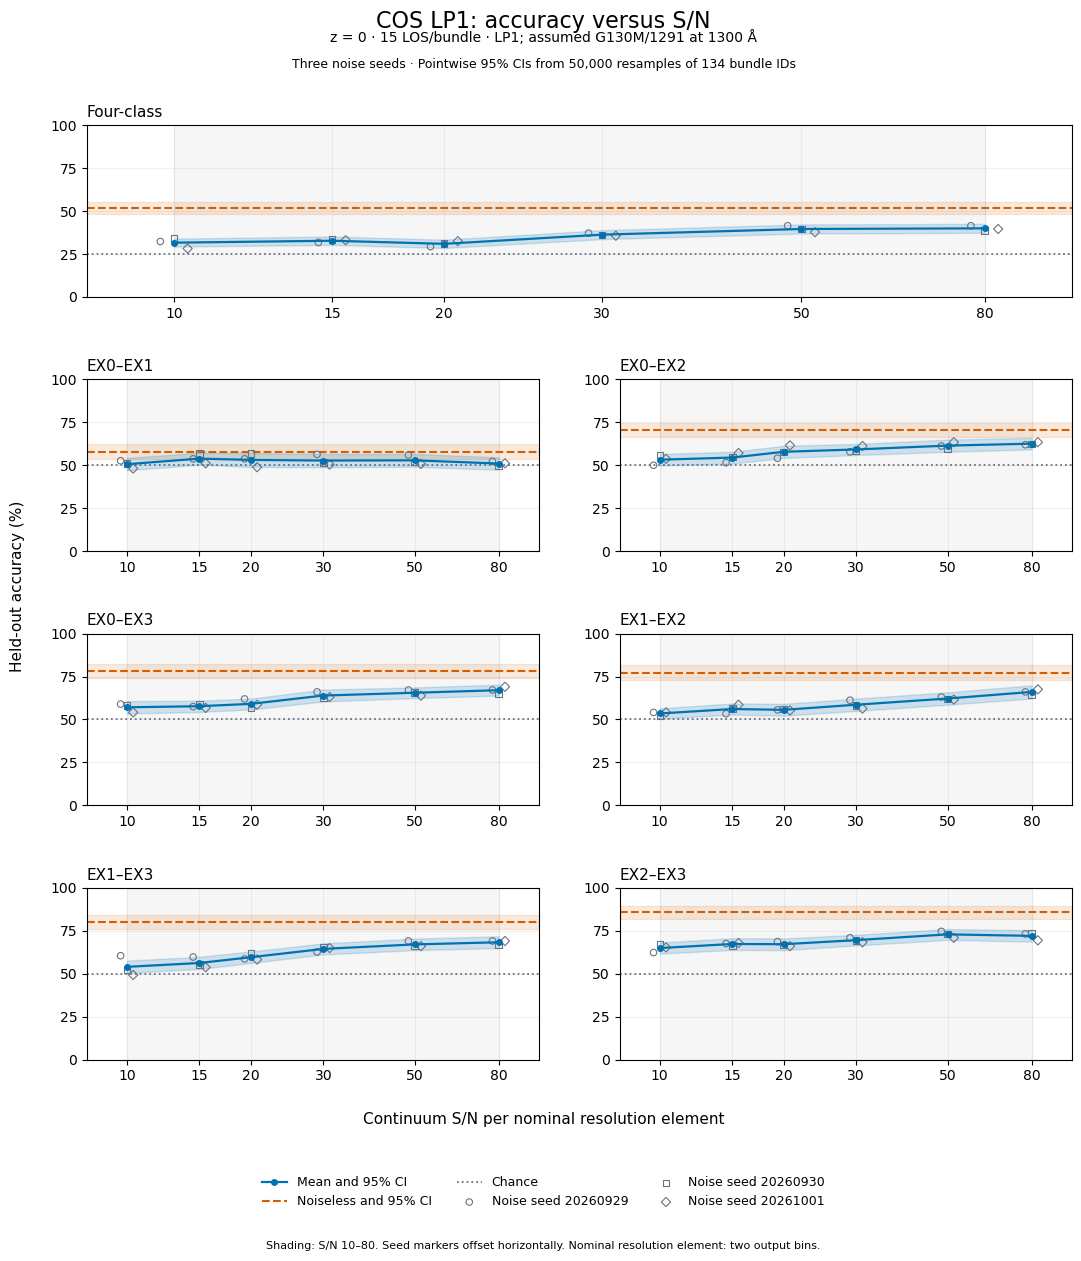

In [29]:
import importlib
from src import snr_plots

importlib.reload(snr_plots)

fig_snr, fig_snr_static = snr_plots.plot_snr_sweep(ROOT)

fig_snr.show(config={"scrollZoom": True, "displaylogo": False})
display(fig_snr_static)

In [30]:
importlib.reload(cos_overlay)

overlay_data = cos_overlay.OverlayData(ROOT)

ranking = overlay_data.rank_table(("EX0", "EX3"), snr_resel=20)
example_los = int(ranking.iloc[0]["los_id"])
native = overlay_data.native_flux(example_los)

print(f"Held-out sightlines: {len(overlay_data.los_ids)}")
print(f"LP1 array: {overlay_data.lp1.shape}")
print(f"Selected native array: {native.shape}")
print(
    f"Sampling: {overlay_data.dv_native:.6f} -> "
    f"{overlay_data.dv_lp1:.6f} km/s"
)

display(pd.concat([ranking.head(3), ranking.tail(3)]).round(3))
display(overlay_data.chi2_table(example_los).round(3))

print({name: find_spec(name) is not None for name in ("ipywidgets", "anywidget")})

EX0: reused EX0.npz
EX1: reused EX1.npz
EX2: reused EX2.npz
EX3: reused EX3.npz
Held-out sightlines: 2010
LP1 array: (4, 2010, 362)
Selected native array: (4, 2499)
Sampling: 1.000400 -> 6.906077 km/s


,rank,los_id,bundle_id,delta_chi2
0,1,5854,390,54853.370
1,2,5906,393,45900.862
2,3,4074,271,45138.621
2007,2008,8769,584,0.075
2008,2009,6543,436,0.072
2009,2010,5003,333,0.053


,S/N 10,S/N 20,S/N 50,S/N 80
model_pair,,,,
EX0-EX1,6.740,26.962,168.511,431.389
EX0-EX2,893.421,3573.684,22335.523,57178.939
EX0-EX3,13713.343,54853.370,342833.563,877653.922
EX1-EX2,777.744,3110.977,19443.605,49775.628
EX1-EX3,13520.434,54081.735,338010.842,865307.755
EX2-EX3,11001.014,44004.058,275025.360,704064.922


{'ipywidgets': True, 'anywidget': True}


In [31]:
from pathlib import Path
import sys
import importlib
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import cos_overlay
importlib.reload(cos_overlay)

overlay_data = cos_overlay.OverlayData(ROOT)
overlay_ui, overlay_figure = cos_overlay.make_overlay_viewer(overlay_data)
display(overlay_ui)

EX0: reused EX0.npz
EX1: reused EX1.npz
EX2: reused EX2.npz
EX3: reused EX3.npz


In [ ]:
importlib.reload(cos_overlay)

overlay_viewer, overlay_figure = cos_overlay.make_overlay_viewer(
    overlay_data
)
display(overlay_viewer)

In [34]:
importlib.reload(cos_overlay)
importlib.reload(cos_oracle)

oracle_flux_cut = 0.85
oracle_settings = {
    "n_draws": 50_000,
    "seed": 20261002,
    "max_chunks": 200,
    "batch_size": 512,
}

oracle_sse, oracle_sightlines, oracle_flux_split = (
    cos_oracle.pair_diagnostics(
        overlay_data,
        flux_cut=oracle_flux_cut,
    )
)

# Confirm agreement with the existing overlay's template separations.
np.testing.assert_allclose(
    oracle_sse,
    overlay_data.squared_diff,
    rtol=1e-12,
    atol=1e-14,
)

oracle_curves, oracle_n95 = cos_oracle.chunk_oracle(
    oracle_sse,
    oracle_flux_split["model_pair"],
    **oracle_settings,
)

oracle_grid = oracle_curves.loc[
    oracle_curves["n_chunks"].isin(cos_oracle.CHUNK_COUNTS)
].copy()

print("Known-field oracle accuracy (%):")
display(
    (
        100 * oracle_grid.pivot(
            index=["model_pair", "snr_resel"],
            columns="n_chunks",
            values="oracle_accuracy",
        )
    ).round(2)
)

print("Estimated N95; >200 means the threshold was not reached:")
display(
    oracle_n95.pivot(
        index="model_pair",
        columns="snr_resel",
        values="n95_display",
    )
)

print("Pooled flux split; min(F_A, F_B) < 0.85:")
display(
    oracle_flux_split.set_index("model_pair")[
        ["low_flux_bin_fraction", "low_flux_chi2_fraction"]
    ].mul(100).rename(columns={
        "low_flux_bin_fraction": "Selected bins (%)",
        "low_flux_chi2_fraction": "Δχ² from selected bins (%)",
    }).round(2)
)

print(
    "Largest Monte Carlo SE: "
    f"{100 * oracle_curves['mc_se'].max():.4f} percentage points"
)

Known-field oracle accuracy (%):


n_chunks                1      2       5       10      13     15     30   \
model_pair snr_resel                                                       
EX0-EX1    10         81.06  91.42   98.96   99.96   99.99  100.0  100.0   
           15         86.21  95.27   99.74  100.00  100.00  100.0  100.0   
           20         89.45  97.14   99.92  100.00  100.00  100.0  100.0   
           30         93.23  98.75   99.99  100.00  100.00  100.0  100.0   
           50         96.63  99.66  100.00  100.00  100.00  100.0  100.0   
           80         98.53  99.93  100.00  100.00  100.00  100.0  100.0   
EX0-EX2    10         79.71  90.27   98.65   99.94   99.99  100.0  100.0   
           15         84.81  94.32   99.62   99.99  100.00  100.0  100.0   
           20         88.10  96.40   99.87  100.00  100.00  100.0  100.0   
           30         92.07  98.32   99.98  100.00  100.00  100.0  100.0   
           50         95.84  99.50  100.00  100.00  100.00  100.0  100.0   
           80         98.07  99.88  100.00  100.00  100.00  100.0  100.0   
EX0-EX3    10         83.66  93.44   99.46   99.99  100.00  100.0  100.0   
           15         88.38  96.52   99.88  100.00  100.00  100.0  100.0   
           20         91.30  97.97   99.97  100.00  100.00  100.0  100.0   
           30         94.68  99.19  100.00  100.00  100.00  100.0  100.0   
           50         97.58  99.81  100.00  100.00  100.00  100.0  100.0   
           80         99.06  99.97  100.00  100.00  100.00  100.0  100.0   
EX1-EX2    10         84.14  93.68   99.48   99.99  100.00  100.0  100.0   
           15         89.24  96.94   99.90  100.00  100.00  100.0  100.0   
           20         92.29  98.36   99.98  100.00  100.00  100.0  100.0   
           30         95.64  99.44  100.00  100.00  100.00  100.0  100.0   
           50         98.29  99.90  100.00  100.00  100.00  100.0  100.0   
           80         99.45  99.99  100.00  100.00  100.00  100.0  100.0   
EX1-EX3    10         86.15  95.20   99.74  100.00  100.00  100.0  100.0   
           15         90.56  97.67   99.95  100.00  100.00  100.0  100.0   
           20         93.10  98.72   99.99  100.00  100.00  100.0  100.0   
           30         95.86  99.51  100.00  100.00  100.00  100.0  100.0   
           50         98.07  99.89  100.00  100.00  100.00  100.0  100.0   
           80         99.15  99.98  100.00  100.00  100.00  100.0  100.0   
EX2-EX3    10         83.18  93.04   99.38   99.98  100.00  100.0  100.0   
           15         88.08  96.32   99.86  100.00  100.00  100.0  100.0   
           20         91.13  97.88   99.96  100.00  100.00  100.0  100.0   
           30         94.66  99.18  100.00  100.00  100.00  100.0  100.0   
           50         97.69  99.83  100.00  100.00  100.00  100.0  100.0   
           80         99.17  99.98  100.00  100.00  100.00  100.0  100.0   

n_chunks                50     100    200  
model_pair snr_resel                       
EX0-EX1    10         100.0  100.0  100.0  
           15         100.0  100.0  100.0  
           20         100.0  100.0  100.0  
           30         100.0  100.0  100.0  
           50         100.0  100.0  100.0  
           80         100.0  100.0  100.0  
EX0-EX2    10         100.0  100.0  100.0  
           15         100.0  100.0  100.0  
           20         100.0  100.0  100.0  
           30         100.0  100.0  100.0  
           50         100.0  100.0  100.0  
           80         100.0  100.0  100.0  
EX0-EX3    10         100.0  100.0  100.0  
           15         100.0  100.0  100.0  
           20         100.0  100.0  100.0  
           30         100.0  100.0  100.0  
           50         100.0  100.0  100.0  
           80         100.0  100.0  100.0  
EX1-EX2    10         100.0  100.0  100.0  
           15         100.0  100.0  100.0  
           20         100.0  100.0  100.0  
           30         100.0  100.0  100.0  
           50         100.0  100.0  100.0  
           

Estimated N95; >200 means the threshold was not reached:


snr_resel,10,15,20,30,50,80
model_pair,,,,,,
EX0-EX1,3,2,2,2,1,1
EX0-EX2,3,3,2,2,1,1
EX0-EX3,3,2,2,2,1,1
EX1-EX2,3,2,2,1,1,1
EX1-EX3,2,2,2,1,1,1
EX2-EX3,3,2,2,2,1,1


Pooled flux split; min(F_A, F_B) < 0.85:


,Selected bins (%),Δχ² from selected bins (%)
model_pair,,
EX0-EX1,5.12,96.01
EX0-EX2,5.19,96.84
EX0-EX3,5.33,97.11
EX1-EX2,5.33,96.49
EX1-EX3,5.39,96.16
EX2-EX3,5.37,97.31


Largest Monte Carlo SE: 0.0721 percentage points


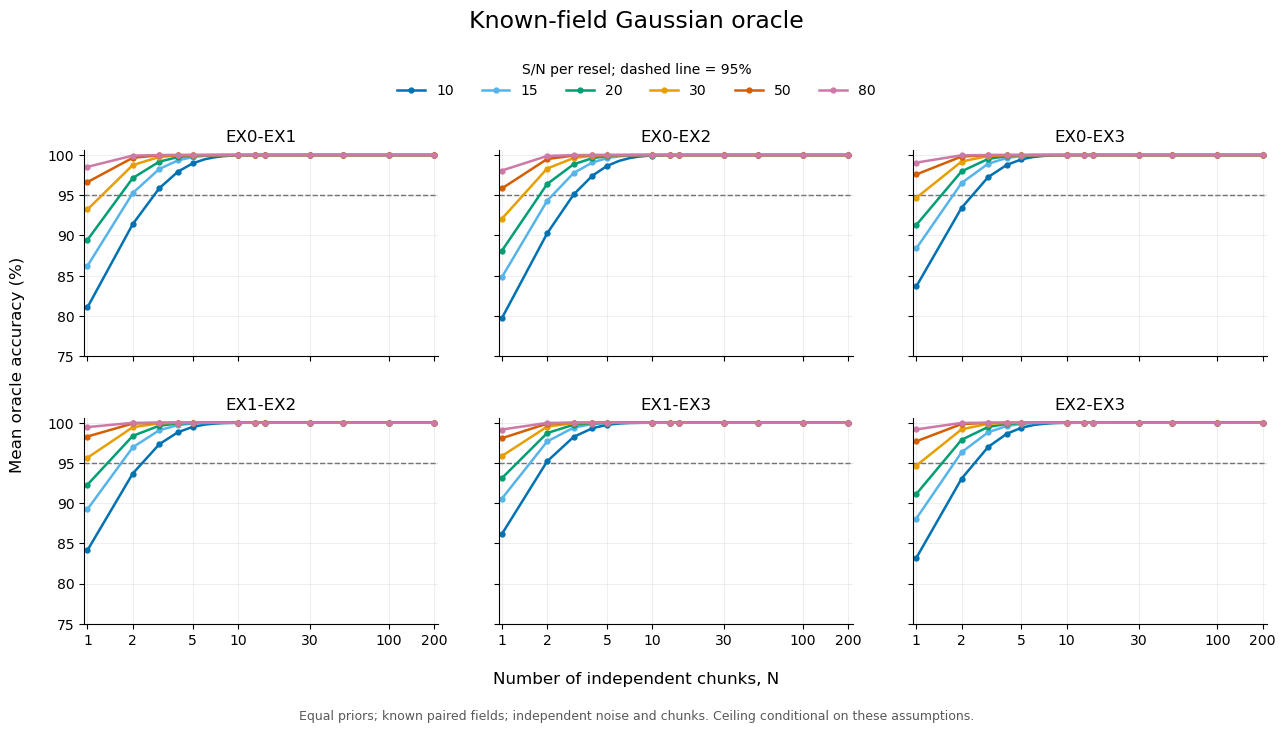

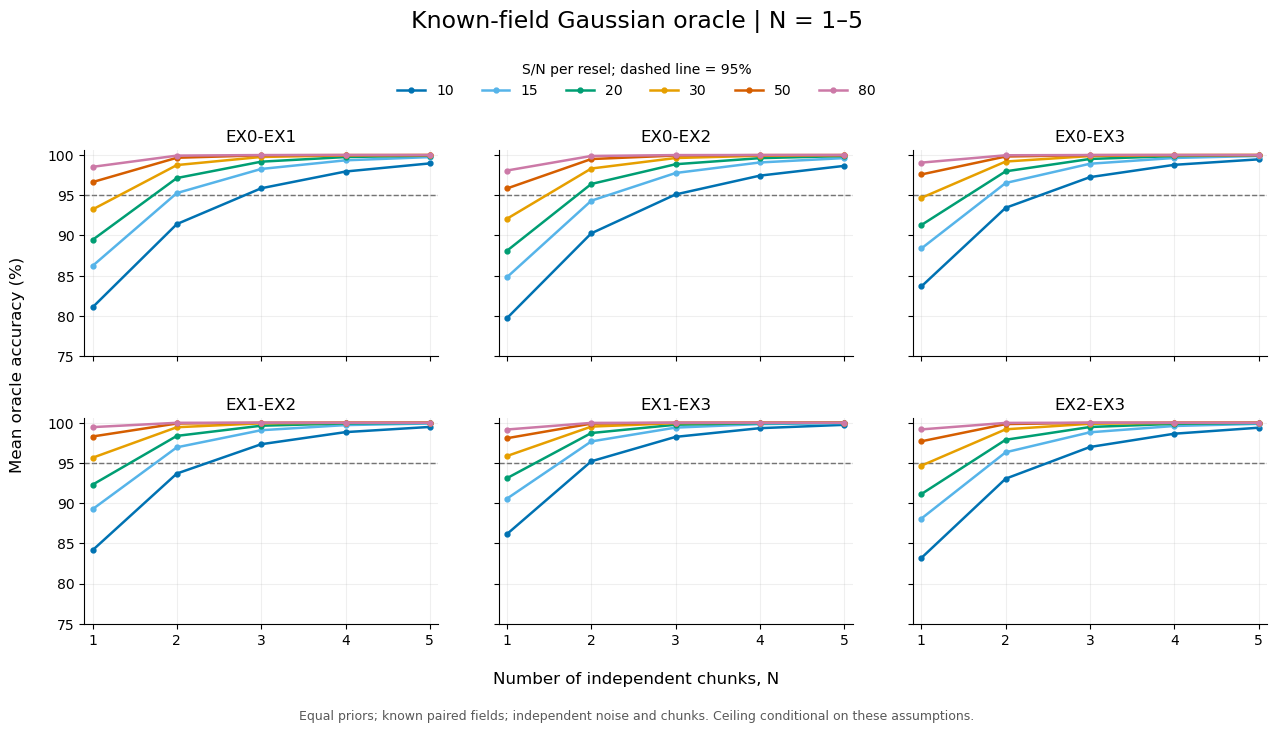

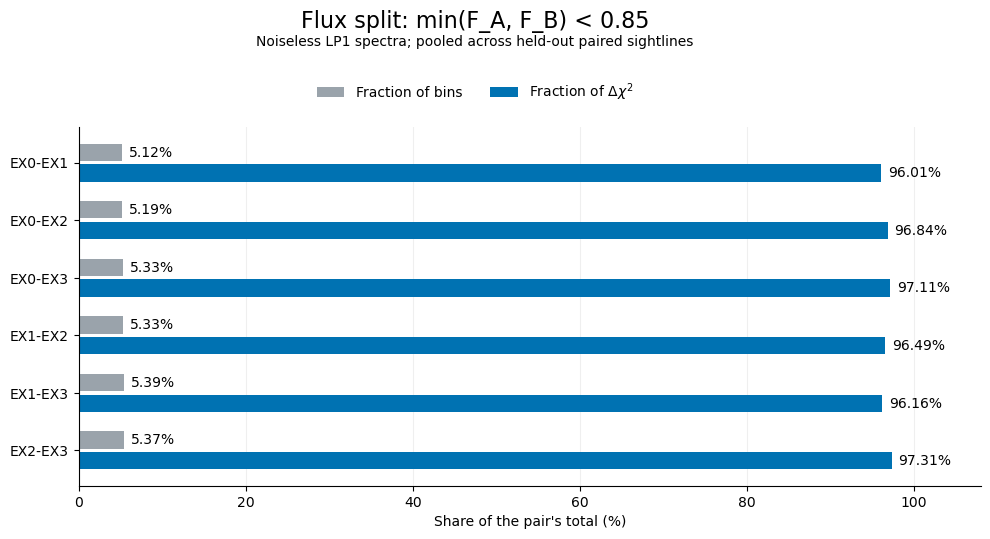

Saved oracle results to /Users/antareepgogoi/Codes/lya_forest_ml/outputs/cos_lsf_snr/oracle


In [35]:
import hashlib
import importlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy
from IPython.display import display

importlib.reload(cos_oracle)

oracle_out = overlay_data.root / "outputs/cos_lsf_snr/oracle"
summary_dir = oracle_out / "summary"
figure_dir = oracle_out / "figures"
summary_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

# Preserve numerical results, including MC standard errors.
for name, table in {
    "oracle_accuracy": oracle_curves,
    "oracle_accuracy_grid": oracle_grid,
    "oracle_n95": oracle_n95,
    "oracle_flux_split": oracle_flux_split,
    "oracle_sightlines": oracle_sightlines,
}.items():
    table.to_csv(summary_dir / f"{name}.csv", index=False)

# Exact numerical inputs for reproducing the chunk calculation.
np.savez_compressed(
    summary_dir / "oracle_inputs.npz",
    squared_difference=oracle_sse,
    los_ids=overlay_data.los_ids,
    bundle_ids=overlay_data.bundle_ids,
    model_pairs=oracle_flux_split["model_pair"].to_numpy(dtype=str),
)

oracle_metadata = {
    "schema_version": 1,
    "settings": oracle_settings,
    "snr_levels": list(cos_oracle.SNR_LEVELS),
    "reported_chunk_counts": list(cos_oracle.CHUNK_COUNTS),
    "flux_cut": oracle_flux_cut,
    "split": "test",
    "n_sightlines": len(overlay_data.los_ids),
    "n_bins_per_chunk": overlay_data.lp1.shape[-1],
    "chunk_length_kms": float(
        overlay_data.dv_lp1 * overlay_data.lp1.shape[-1]
    ),
    "class_priors": [0.5, 0.5],
    "noise": "Independent Gaussian bins; sigma_bin = sqrt(2) / SNR_resel",
    "chunk_sampling": "Uniform with replacement from held-out paired LOS",
    "shared_draws": "Same LOS sequences across pairs, SNR levels and N",
    "n95_definition": (
        "First integer N with estimated mean accuracy >= 0.95; "
        "censored above max_chunks"
    ),
    "flux_split_definition": (
        "Sum of squared differences in selected bins divided by "
        "sum over all bins and held-out sightlines"
    ),
    "mc_se_scope": "Monte Carlo integration error only; excludes cosmic variance",
    "interpretation": (
        "Known-field oracle ceiling; credits line-position differences"
    ),
    "source_lp1_metadata": overlay_data.metadata,
    "oracle_code_sha256": hashlib.sha256(
        Path(cos_oracle.__file__).read_bytes()
    ).hexdigest(),
    "versions": {
        "numpy": np.__version__,
        "scipy": scipy.__version__,
    },
}

(summary_dir / "oracle_metadata.json").write_text(
    json.dumps(oracle_metadata, indent=2, allow_nan=False) + "\n",
    encoding="utf-8",
)

oracle_figures = cos_oracle.plot_oracle_results(
    oracle_curves,
    oracle_flux_split,
)

for name, fig in oracle_figures.items():
    fig.savefig(figure_dir / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(
        figure_dir / f"{name}.png",
        dpi=200,
        bbox_inches="tight",
    )
    display(fig)
    plt.close(fig)

print(f"Saved oracle results to {oracle_out}")

In [36]:
import importlib
from IPython.display import display
from src import cos_absorbers

importlib.reload(cos_absorbers)

absorber_census = cos_absorbers.build_absorber_census(
    overlay_data,
    flux_cuts=(0.85, 0.95),
    match_kms=30.0,
    strong_cut=0.5,
)
absorber_summary = absorber_census["summary"]

settings = absorber_census["settings"]
print(
    "Total velocity path per model: "
    f"{settings['n_los'] * settings['path_per_los_kms']:,.0f} km/s"
)

print("Counts and incidence:")
display(
    absorber_summary[[
        "flux_cut", "model",
        "n_detected", "detected_per_1e4_kms",
        "n_unique_all", "unique_all_per_1e4_kms",
        "n_isolated_all", "n_competition", "n_weaker_neighbor",
    ]].round(3)
)

print("Pairwise unmatched counts: row model relative to column model")
display(
    absorber_census["pair_summary"].pivot(
        index=["flux_cut", "model"],
        columns="other_model",
        values="n_unmatched",
    ).astype("Int64")
)

print("Properties of detections unmatched against all other models:")
display(
    absorber_summary[[
        "flux_cut", "model",
        "unique_median_depth",
        "unique_inside_strong_fraction",
        "unique_no_strong_fraction",
        "unique_outside_median_distance_kms",
    ]].round(3)
)

Total velocity path per model: 5,025,000 km/s
Counts and incidence:


,flux_cut,model,n_detected,detected_per_1e4_kms,n_unique_all,unique_all_per_1e4_kms,n_isolated_all,n_competition,n_weaker_neighbor
0,0.85,EX0,3076,6.121,116,0.231,111,5,65
1,0.85,EX1,3047,6.064,169,0.336,167,2,104
2,0.85,EX2,3087,6.143,140,0.279,139,1,90
3,0.85,EX3,3278,6.523,306,0.609,298,8,181
4,0.95,EX0,6193,12.324,199,0.396,189,10,0
5,0.95,EX1,6027,11.994,264,0.525,251,13,0
6,0.95,EX2,6245,12.428,169,0.336,159,10,0
7,0.95,EX3,6784,13.500,527,1.049,506,21,0


Pairwise unmatched counts: row model relative to column model


other_model      EX0   EX1   EX2   EX3
flux_cut model                        
0.85     EX0    <NA>   473   414   478
         EX1     444  <NA>   546   532
         EX2     425   586  <NA>   469
         EX3     680   763   660  <NA>
0.95     EX0    <NA>   916   678   689
         EX1     750  <NA>   903   744
         EX2     730  1121  <NA>   625
         EX3    1280  1501  1164  <NA>

Properties of detections unmatched against all other models:


,flux_cut,model,unique_median_depth,unique_inside_strong_fraction,unique_no_strong_fraction,unique_outside_median_distance_kms
0,0.85,EX0,0.225,0.147,0.560,410.912
1,0.85,EX1,0.179,0.118,0.533,514.503
2,0.85,EX2,0.206,0.171,0.557,366.022
3,0.85,EX3,0.187,0.144,0.529,435.083
4,0.95,EX0,0.075,0.075,0.613,504.144
5,0.95,EX1,0.077,0.068,0.549,328.039
6,0.95,EX2,0.082,0.089,0.580,441.989
7,0.95,EX3,0.068,0.072,0.598,466.160


Paired bootstrap bundles: 134
Positive differences mean EX3 has the higher value:


,flux_cut,metric,comparison,difference,low,high,unit
8,0.85,unique_rate,EX3 - EX0,0.378,0.293,0.468,per 10000 km/s
10,0.85,unique_rate,EX3 - EX1,0.273,0.181,0.368,per 10000 km/s
11,0.85,unique_rate,EX3 - EX2,0.330,0.243,0.418,per 10000 km/s
20,0.85,isolated_broad_rate,EX3 - EX0,0.141,0.096,0.189,per 10000 km/s
22,0.85,isolated_broad_rate,EX3 - EX1,0.107,0.060,0.155,per 10000 km/s
23,0.85,isolated_broad_rate,EX3 - EX2,0.135,0.086,0.187,per 10000 km/s
26,0.85,unique_percent,EX3 - EX0,5.564,4.316,6.847,pp
28,0.85,unique_percent,EX3 - EX1,3.789,2.422,5.194,pp
29,0.85,unique_percent,EX3 - EX2,4.800,3.512,6.094,pp
38,0.95,unique_rate,EX3 - EX0,0.653,0.559,0.748,per 10000 km/s


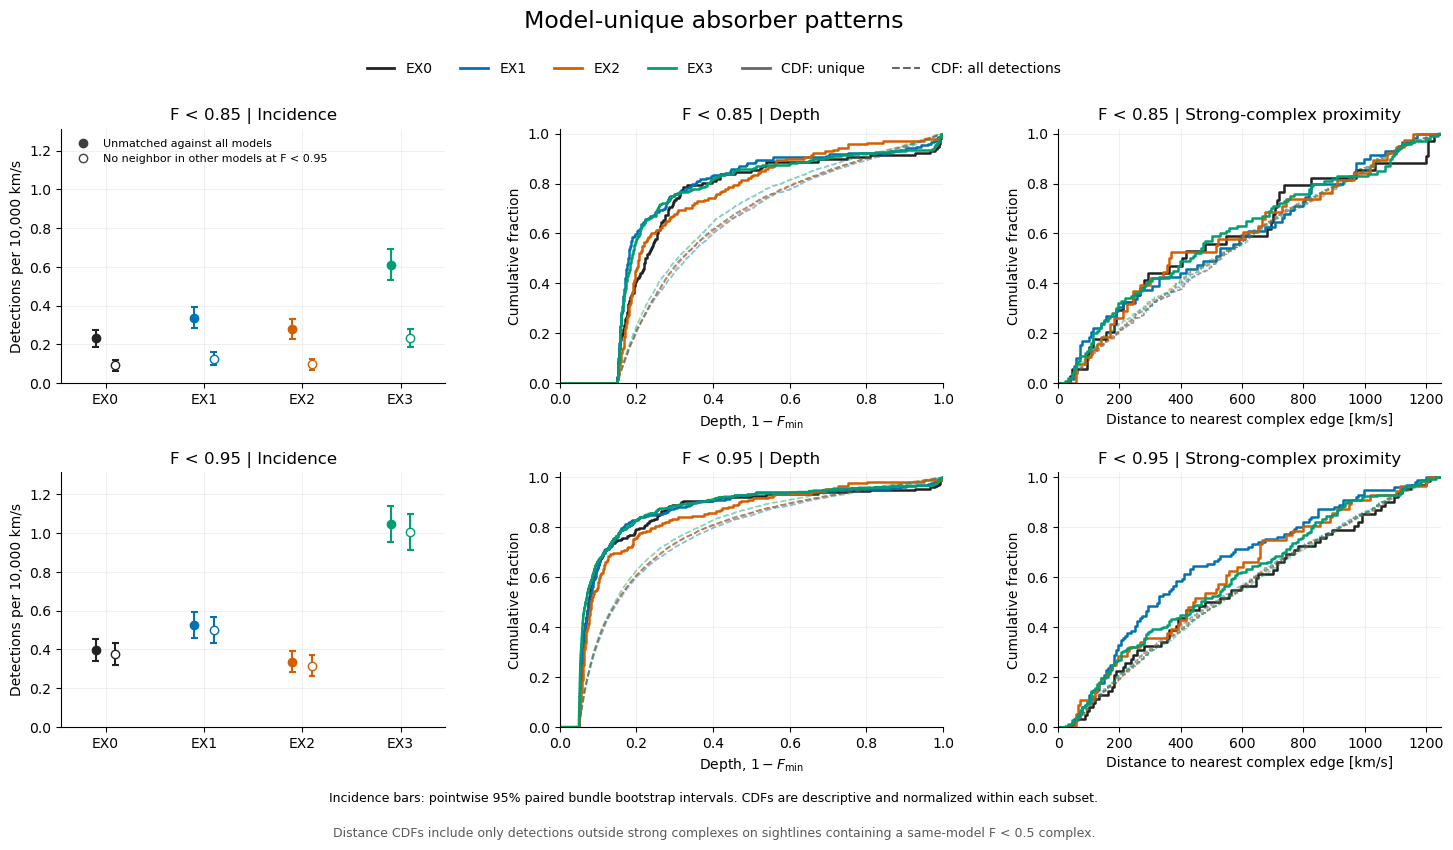

,flux_cut,model,n_unique_all,unique_median_depth,inside_strong_pct,no_strong_complex_pct,unique_outside_median_distance_kms
0,0.85,EX0,116,0.23,14.66,56.03,410.91
1,0.85,EX1,169,0.18,11.83,53.25,514.50
2,0.85,EX2,140,0.21,17.14,55.71,366.02
3,0.85,EX3,306,0.19,14.38,52.94,435.08
4,0.95,EX0,199,0.07,7.54,61.31,504.14
5,0.95,EX1,264,0.08,6.82,54.92,328.04
6,0.95,EX2,169,0.08,8.88,57.99,441.99
7,0.95,EX3,527,0.07,7.21,59.77,466.16


In [37]:
import importlib
import matplotlib.pyplot as plt
from IPython.display import display

importlib.reload(cos_absorbers)

absorber_inference = cos_absorbers.bootstrap_absorber_rates(
    absorber_census,
    n_draws=50_000,
    seed=20261003,
)

print(
    "Paired bootstrap bundles:",
    absorber_inference["settings"]["n_bundles"],
)

contrasts = absorber_inference["contrasts"]
focus = contrasts.loc[
    (contrasts["model_b"] == "EX3")
    & contrasts["metric"].isin([
        "unique_rate",
        "isolated_broad_rate",
        "unique_percent",
    ])
]

print("Positive differences mean EX3 has the higher value:")
display(
    focus[[
        "flux_cut", "metric", "comparison",
        "difference", "low", "high", "unit",
    ]].round(3)
)

absorber_pattern_figure = cos_absorbers.plot_absorber_patterns(
    absorber_census,
    absorber_inference,
)
display(absorber_pattern_figure)
plt.close(absorber_pattern_figure)

environment = absorber_census["summary"].copy()
environment["inside_strong_pct"] = (
    100 * environment["unique_inside_strong_fraction"]
)
environment["no_strong_complex_pct"] = (
    100 * environment["unique_no_strong_fraction"]
)

display(
    environment[[
        "flux_cut", "model", "n_unique_all",
        "unique_median_depth",
        "inside_strong_pct",
        "no_strong_complex_pct",
        "unique_outside_median_distance_kms",
    ]].round(2)
)

In [38]:
from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json
import platform

import matplotlib
import numpy as np
import pandas as pd
import scipy

absorber_output = (
    Path(overlay_data.root) / "outputs" / "cos_lsf_snr" / "absorbers"
)
summary_dir = absorber_output / "summary"
figure_dir = absorber_output / "figures"
summary_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

absorber_tables = {
    f"absorber_{name}": absorber_census[name]
    for name in (
        "catalog",
        "detections",
        "pair_status",
        "los_counts",
        "summary",
        "pair_summary",
    )
}
absorber_tables.update({
    f"absorber_{name}": absorber_inference[name]
    for name in ("rates", "contrasts", "bundle_counts")
})

for name, table in absorber_tables.items():
    table.to_csv(summary_dir / f"{name}.csv", index=False)

source_file = Path(cos_absorbers.__file__)

absorber_metadata = {
    "schema_version": 1,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "models": list(overlay_data.models),
    "n_test_sightlines": int(len(overlay_data.los_ids)),
    "n_test_bundles": int(len(np.unique(overlay_data.bundle_ids))),
    "dv_lp1_kms": float(overlay_data.dv_lp1),
    "census_settings": absorber_census["settings"],
    "bootstrap_settings": absorber_inference["settings"],
    "source_lp1_metadata": overlay_data.metadata,
    "source_code_file": "src/cos_absorbers.py",
    "source_code_sha256": hashlib.sha256(
        source_file.read_bytes()
    ).hexdigest(),
    "versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "matplotlib": matplotlib.__version__,
    },
    "definitions": {
        "unique_all": "Unmatched against every other model.",
        "isolated_broad": (
            "No neighboring detection in any other model within the "
            "matching window, using the broadest flux-cut catalog."
        ),
        "depth": "1 - F_min",
        "distance": (
            "Periodic distance to the nearest same-model strong-complex "
            "edge; zero inside a complex; missing when none exists."
        ),
        "distance_plot_population": (
            "Outside strong complexes, on sightlines containing at "
            "least one same-model strong complex."
        ),
    },
    "scope": (
        "Noiseless LP1 census. Bootstrap intervals are pointwise and "
        "conditional on the frozen calibration, test split, and "
        "simulation volumes. Depth and distance CDFs are descriptive."
    ),
}


def _absorber_json_default(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    raise TypeError(f"Cannot serialize {type(value).__name__}")


(summary_dir / "absorber_metadata.json").write_text(
    json.dumps(
        absorber_metadata,
        indent=2,
        default=_absorber_json_default,
        allow_nan=False,
    ) + "\n",
    encoding="utf-8",
)

absorber_pattern_figure.savefig(
    figure_dir / "absorber_patterns.pdf", bbox_inches="tight"
)
absorber_pattern_figure.savefig(
    figure_dir / "absorber_patterns.png",
    dpi=200,
    bbox_inches="tight",
)

display(pd.DataFrame([
    {"file": f"{name}.csv", "rows": len(table)}
    for name, table in absorber_tables.items()
]))
print(f"Saved tables, metadata, PDF, and PNG to:\n{absorber_output}")

,file,rows
0,absorber_catalog.csv,25249
1,absorber_detections.csv,37737
2,absorber_pair_status.csv,113211
3,absorber_los_counts.csv,16080
4,absorber_summary.csv,8
5,absorber_pair_summary.csv,24
6,absorber_rates.csv,40
7,absorber_contrasts.csv,60
8,absorber_bundle_counts.csv,1072


Saved tables, metadata, PDF, and PNG to:
/Users/antareepgogoi/Codes/lya_forest_ml/outputs/cos_lsf_snr/absorbers
